# CIFAR-10 : Exercices 6 & 7

On classe les images CIFAR-10 sans réseau de neurones, avec des méthodes
classiques d'optimisation et d'algèbre linéaire (SVM, noyaux, PCA, K-means).
L'exercice 6 traite la classification supervisée (SVM, puis passage à l'échelle
par Nyström) ; l'exercice 7 apprend des représentations sans étiquettes.

Le même outil revient souvent : la diagonalisation des matrices symétriques
(théorème spectral), qui sert pour la PCA comme pour Nyström.

## 0. Chargement de CIFAR-10

50 000 images d'entraînement + 10 000 de test, $32\times32\times3 = 3072$ pixels,
10 classes équilibrées. On charge directement l'archive *python* (pickle), sans
`torchvision`.


X_train : (50000, 3072) | X_test : (10000, 3072)
classes : ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
équilibre (train) : [5000 5000 5000 5000 5000 5000 5000 5000 5000 5000]


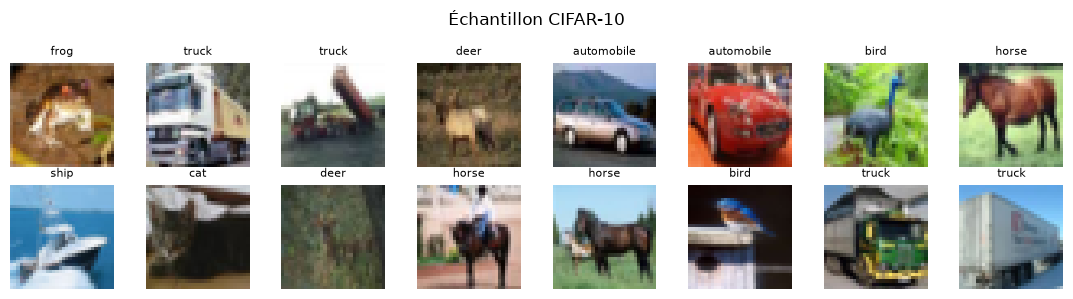

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pickle, time
from pathlib import Path
import matplotlib.pyplot as plt

ROOT = Path("data_cifar/cifar-10-batches-py")

def _load(f):
    with open(ROOT / f, "rb") as fo:
        d = pickle.load(fo, encoding="latin1")
    return d["data"].astype("float32"), np.array(d["labels"])

X_train = np.concatenate([_load(f"data_batch_{i}")[0] for i in range(1, 6)])
y_train = np.concatenate([_load(f"data_batch_{i}")[1] for i in range(1, 6)])
X_test,  y_test  = _load("test_batch")
with open(ROOT / "batches.meta", "rb") as fo:
    CLASSES = pickle.load(fo, encoding="latin1")["label_names"]

print("X_train :", X_train.shape, "| X_test :", X_test.shape)
print("classes :", CLASSES)
print("équilibre (train) :", np.bincount(y_train))

# Vue (N, 32, 32, 3) pour les patches / l'affichage
to_img = lambda X: X.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
I_train, I_test = to_img(X_train), to_img(X_test)

fig, ax = plt.subplots(2, 8, figsize=(11, 3))
for k, a in enumerate(ax.ravel()):
    a.imshow(I_train[k].astype("uint8")); a.axis("off"); a.set_title(CLASSES[y_train[k]], fontsize=8)
plt.suptitle("Échantillon CIFAR-10"); plt.tight_layout(); plt.show()


**Protocole.** Le test (10 000) n'est jamais utilisé pour choisir un modèle ou
un hyperparamètre. Le SVM à noyau **exact** ayant une matrice de Gram $n\times n$
(coût $O(n^2)$ mémoire), on l'évalue sur un **sous-échantillon** 10 000/2 000 ;
les méthodes linéaires, Nyström, PCA et K-means utilisent les données complètes.


In [2]:
rng = np.random.default_rng(0)
ns_tr, ns_te = 10000, 2000          # sous-échantillon pour le noyau EXACT
Xs, ys = X_train[:ns_tr], y_train[:ns_tr]
Xt, yt = X_test[:ns_te],  y_test[:ns_te]
print(f"Sous-échantillon noyau exact : {ns_tr} train / {ns_te} test")


Sous-échantillon noyau exact : 10000 train / 2000 test


# Exercice 6 : Classification supervisée

Objectif : associer une image à sa classe. On commence par quelques baselines,
puis on dérive le SVM, et enfin on le passe à l'échelle avec Nyström.

## 6.1 Baselines : $k$-NN, régression softmax, SVM linéaire

- **$k$-NN** : prédit la classe majoritaire parmi les $k$ plus proches voisins.
  Aucune optimisation ; tout est dans la distance. Sert la discussion
  **biais-variance** ($k$ petit = variance forte, $k$ grand = biais fort).
- **Régression softmax** (logistique multiclasse) : modèle
  $p(y=c\mid x)=\dfrac{e^{w_c^\top x}}{\sum_j e^{w_j^\top x}}$, entraîné en
  minimisant l'**entropie croisée**
  $-\sum_i \log p(y_i\mid x_i)$ — fonction **convexe**, gradient explicite.
- **SVM linéaire** : minimise la **perte hinge** régularisée
  $\frac12\lVert w\rVert^2 + C\sum_i \max(0,\,1-y_i(w^\top x_i+b))$ (cf. 6.2).


In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score

print(f"{'Modèle':<26}{'acc test (2k)':>14}{'temps':>9}")
print("-" * 49)
baselines = {
    "k-NN (k=10)"        : make_pipeline(StandardScaler(), KNeighborsClassifier(10)),
    "Softmax (entr. cr.)": make_pipeline(StandardScaler(), LogisticRegression(max_iter=200)),
    "SVM linéaire (hinge)": make_pipeline(StandardScaler(), LinearSVC(C=0.01, dual="auto", max_iter=3000)),
}
res6 = {}
for name, m in baselines.items():
    t = time.time(); m.fit(Xs, ys)
    acc = accuracy_score(yt, m.predict(Xt)); dt = time.time() - t
    res6[name] = acc
    print(f"{name:<26}{acc:>14.3f}{dt:>8.1f}s")


Modèle                     acc test (2k)    temps
-------------------------------------------------


k-NN (k=10)                        0.281     0.4s


Softmax (entr. cr.)                0.292     1.3s


SVM linéaire (hinge)               0.308   113.5s


## 6.2 SVM à marge maximale d'après le cours de SVM

**Primal (marge dure).** Pour des données séparables $\{(x_i,y_i)\}$, $y_i\in\{\pm1\}$,
l'hyperplan $w^\top x+b=0$ a une marge $2/\lVert w\rVert$. La maximiser revient à
$$\min_{w,b}\ \tfrac12\lVert w\rVert^2 \quad\text{s.c.}\quad y_i(w^\top x_i+b)\ge 1\ \ \forall i.$$

**Marge souple.** Pour des données non séparables, on ajoute des variables d'écart
$\xi_i\ge0$ :
$$\min_{w,b,\xi}\ \tfrac12\lVert w\rVert^2 + C\sum_i \xi_i
\quad\text{s.c.}\quad y_i(w^\top x_i+b)\ge 1-\xi_i,\ \ \xi_i\ge0.$$
À l'optimum $\xi_i=\max(0,1-y_i(w^\top x_i+b))$ : c'est la perte hinge.

**Lagrangien.** Avec les multiplicateurs $\alpha_i\ge0$ (marge) et $\mu_i\ge0$ ($\xi_i\ge0$) :
$$\mathcal L=\tfrac12\lVert w\rVert^2+C\sum_i\xi_i-\sum_i\alpha_i\big[y_i(w^\top x_i+b)-1+\xi_i\big]-\sum_i\mu_i\xi_i.$$
En annulant les dérivées :
$$w=\sum_i\alpha_i y_i x_i,\qquad
\sum_i\alpha_i y_i=0,\qquad
\alpha_i=C-\mu_i.$$

**Dual.** En réinjectant :
$$\max_{\alpha}\ \sum_i\alpha_i-\tfrac12\sum_{i,j}\alpha_i\alpha_j\,y_iy_j\,\langle x_i,x_j\rangle
\quad\text{s.c.}\quad 0\le\alpha_i\le C,\ \sum_i\alpha_i y_i=0.$$
Problème quadratique concave : les données n'apparaissent que par produits scalaires.

**KKT et vecteurs supports.** La complémentarité $\alpha_i\big[y_i(w^\top x_i+b)-1+\xi_i\big]=0$
impose $\alpha_i\neq0$ uniquement pour les points sur ou dans la marge, les
vecteurs supports : la solution ne dépend que d'eux.

**Kernel trick.** Comme tout passe par $\langle x_i,x_j\rangle$, on remplace le
produit scalaire par un noyau $k(x_i,x_j)=\langle\varphi(x_i),\varphi(x_j)\rangle$
(pour un noyau symétrique défini positif, un tel $\varphi$ existe : théorème de
Mercer). On obtient le classifieur $f(x)=\sum_i\alpha_i y_i\,k(x_i,x)+b$, et on
utilise le noyau RBF $\exp(-\gamma\lVert x-x'\rVert^2)$ pour la non-linéarité.

In [4]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# --- Sélection de (C, gamma) par validation croisée ---
# Le noyau exact est coûteux : on règle les hyperparamètres par CV (3 plis) sur un
# sous-échantillon de l'entraînement (3000 images), puis on ré-entraîne le meilleur
# modèle sur les 10 000 images et on évalue UNE seule fois sur le test.
n_cv = 3000
Xcv, ycv = Xs[:n_cv], ys[:n_cv]
grid = {"svc__C": [1, 10, 100], "svc__gamma": ["scale", 1e-3, 1e-2]}

gs = GridSearchCV(
    make_pipeline(StandardScaler(), SVC(kernel="rbf")),
    grid, cv=StratifiedKFold(3, shuffle=True, random_state=0),
    scoring="accuracy", n_jobs=-1,
)
t = time.time()
gs.fit(Xcv, ycv)
print(f"GridSearchCV (3 plis, {len(grid['svc__C'])*len(grid['svc__gamma'])} combinaisons) "
      f"en {time.time()-t:.1f}s")
print(f"  meilleurs hyperparamètres : {gs.best_params_}  (acc CV = {gs.best_score_:.3f})")

# --- Ré-entraînement du meilleur modèle sur les 10 000 images ---
t = time.time()
svc = make_pipeline(StandardScaler(),
                    SVC(kernel="rbf",
                        C=gs.best_params_["svc__C"],
                        gamma=gs.best_params_["svc__gamma"]))
svc.fit(Xs, ys)
acc_rbf = accuracy_score(yt, svc.predict(Xt))
nsv = svc[-1].n_support_.sum()
print(f"SVM RBF exact (10k, hyperparams. CV) : acc test = {acc_rbf:.3f}  en {time.time()-t:.1f}s")
print(f"  vecteurs supports : {nsv} / {ns_tr} "
      f"({100*nsv/ns_tr:.0f}% des points définissent la frontière)")
res6["SVM RBF exact (10k)"] = acc_rbf


GridSearchCV (3 plis, 9 combinaisons) en 34.4s
  meilleurs hyperparamètres : {'svc__C': 10, 'svc__gamma': 'scale'}  (acc CV = 0.418)


SVM RBF exact (10k, hyperparams. CV) : acc test = 0.479  en 74.6s
  vecteurs supports : 9616 / 10000 (96% des points définissent la frontière)


### Visualisation de la frontière SVM (projection 2D)

Pour *voir* la forme d'une frontière SVM à noyau RBF, on se place dans un cas
lisible : deux classes seulement, et les images projetées sur leurs deux premières
composantes principales (PCA). Le SVM est entraîné sur cette projection 2D. La
frontière (trait plein) et la marge (pointillés à $\pm1$) apparaissent clairement.
Le fort recouvrement des deux classes rappelle qu'en passant de $3072$ à $2$
dimensions on perd presque toute l'information : ce modèle 2D n'est là que pour
l'illustration.

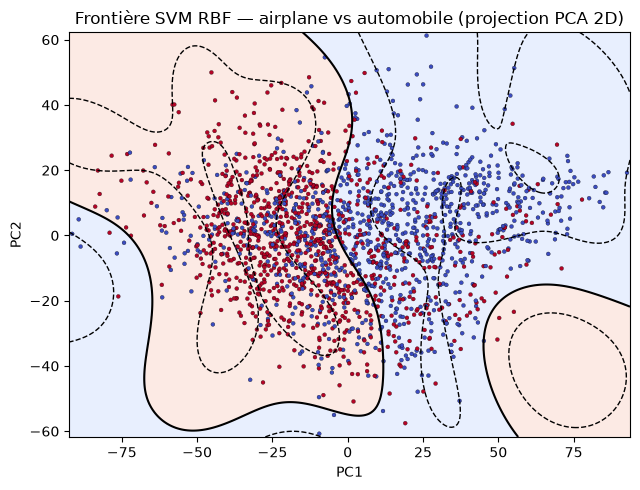

Trait plein = frontière (decision_function = 0) ; pointillés = marge (±1).
Les deux classes se recoupent fortement : en 2D on perd l'essentiel des 3072 pixels.


In [5]:
from sklearn.decomposition import PCA

# Deux classes seulement, projetées en 2D, pour visualiser la frontière RBF.
cls_a, cls_b = 0, 1                       # avion vs automobile
mask = np.isin(ys, [cls_a, cls_b])
Xb, yb = Xs[mask], (ys[mask] == cls_b).astype(int)

proj = make_pipeline(StandardScaler(), PCA(n_components=2, random_state=0)).fit(Xb)
Z = proj.transform(Xb)
svc2d = SVC(C=10, gamma="scale").fit(Z, yb)

xx, yy = np.meshgrid(np.linspace(Z[:, 0].min()-1, Z[:, 0].max()+1, 300),
                     np.linspace(Z[:, 1].min()-1, Z[:, 1].max()+1, 300))
dec = svc2d.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(6.5, 5))
plt.contourf(xx, yy, dec > 0, alpha=0.2, cmap="coolwarm")
plt.contour(xx, yy, dec, levels=[-1, 0, 1], colors="k",
            linestyles=["--", "-", "--"], linewidths=[1, 1.5, 1])   # marge ± frontière
plt.scatter(Z[:, 0], Z[:, 1], c=yb, cmap="coolwarm", s=8, edgecolor="k", linewidth=0.2)
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.title(f"Frontière SVM RBF — {CLASSES[cls_a]} vs {CLASSES[cls_b]} (projection PCA 2D)")
plt.tight_layout(); plt.show()
print("Trait plein = frontière (decision_function = 0) ; pointillés = marge (±1).")
print("Les deux classes se recoupent fortement : en 2D on perd l'essentiel des 3072 pixels.")


## 6.3 Passage à l'échelle : approximation de Nyström

Le SVM RBF exact exige la matrice de Gram $K\in\mathbb R^{n\times n}$,
$K_{ij}=k(x_i,x_j)$. Pour $n=50\,000$ cela fait ~20 Go. Nyström approxime $K$ par
une matrice de rang faible $m\ll n$.

**Construction.** On tire $m$ points de référence (*landmarks*) et on forme les blocs
$$C\in\mathbb R^{n\times m}\ (\text{tous}\times\text{landmarks}),\qquad
W\in\mathbb R^{m\times m}\ (\text{landmarks}\times\text{landmarks}),$$
$$\tilde K = C\,W^{+}\,C^\top\quad(\text{rang}\le m),\qquad W^{+}=\text{pseudo-inverse}.$$

**Features explicites.** On diagonalise le petit bloc $W=U\Lambda U^\top$ et on pose
$$Z = C\,U\,\Lambda^{-1/2}\in\mathbb R^{n\times m}.$$
Alors $ZZ^\top = C\,U\Lambda^{-1}U^\top C^\top = C\,W^{+}C^\top = \tilde K$, donc
$\langle z_i,z_j\rangle\approx k(x_i,x_j)$ : chaque image reçoit un vecteur
$z_i\in\mathbb R^m$. Le SVM à noyau devient alors un SVM linéaire dans $\mathbb R^m$
(`LinearSVC`, coût $O(nm)$), applicable aux 50 000 images sans jamais former $K$.

L'approximation est bonne quand le spectre de $K$ décroît vite (cas du RBF) : $K$
est alors presque de rang faible, comme pour Eckart-Young en PCA (Ex 7). On vérifie
d'abord $\lVert K-\tilde K\rVert_F$ sur un petit bloc, puis on entraîne sur les
50 000 images.

In [6]:
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.kernel_approximation import Nystroem

# --- (a) qualité de l'approximation sur un bloc 1500x1500 ---
sub = StandardScaler().fit_transform(X_train[:1500])
g = 1.0 / X_train.shape[1]                       # = gamma 'scale' après standardisation (var=1)
K = rbf_kernel(sub, gamma=g)
for m in [50, 150, 400]:
    ny = Nystroem(kernel="rbf", gamma=g, n_components=m, random_state=0)
    Z = ny.fit_transform(sub)                     # Z = C U Λ^{-1/2}
    Kt = Z @ Z.T                                  # ≈ K
    err = np.linalg.norm(K - Kt) / np.linalg.norm(K)
    print(f"m={m:4d}  ||K - ZZ^T||_F / ||K||_F = {err:.3f}")
print("→ l'erreur chute quand m croît : le spectre RBF décroît vite.\n")


m=  50  ||K - ZZ^T||_F / ||K||_F = 0.167
m= 150  ||K - ZZ^T||_F / ||K||_F = 0.093
m= 400  ||K - ZZ^T||_F / ||K||_F = 0.059
→ l'erreur chute quand m croît : le spectre RBF décroît vite.



In [7]:
# --- (b) Nyström + SVM linéaire sur les 50 000 images (test complet 10k) ---
print(f"{'Méthode':<34}{'acc test (10k)':>15}{'temps':>9}")
print("-" * 58)
for m in [500, 1000]:
    t = time.time()
    pipe = make_pipeline(StandardScaler(),
                         Nystroem(kernel="rbf", gamma=g, n_components=m, random_state=0),
                         LinearSVC(C=1, dual="auto", max_iter=3000))
    pipe.fit(X_train, y_train)
    acc = accuracy_score(y_test, pipe.predict(X_test))
    res6[f"Nyström m={m} (50k)"] = acc
    print(f"{'Nyström RBF m='+str(m)+' (50k)':<34}{acc:>15.3f}{time.time()-t:>8.1f}s")


Méthode                            acc test (10k)    temps
----------------------------------------------------------


Nyström RBF m=500 (50k)                     0.481    55.0s


Nyström RBF m=1000 (50k)                    0.504    93.4s


## 6.4 Bilan — Exercice 6

Le SVM RBF **exact** sur 10 000 images et **Nyström** sur les **50 000** atteignent
une précision comparable **pour un coût similaire** : Nyström exploite 5× plus de
données sans jamais former la matrice de Gram. En pixels bruts, on plafonne
néanmoins vers ~50 % : la limite n'est pas l'optimiseur mais la **représentation**.
D'où l'exercice 7.


In [8]:
order = ["k-NN (k=10)", "Softmax (entr. cr.)", "SVM linéaire (hinge)",
         "SVM RBF exact (10k)", "Nyström m=500 (50k)", "Nyström m=1000 (50k)"]
print(f"{'Modèle':<26}{'acc test':>10}")
print("-" * 36)
for k in order:
    print(f"{k:<26}{res6[k]:>10.3f}")


Modèle                      acc test
------------------------------------
k-NN (k=10)                    0.281
Softmax (entr. cr.)            0.292
SVM linéaire (hinge)           0.308
SVM RBF exact (10k)            0.479
Nyström m=500 (50k)            0.481
Nyström m=1000 (50k)           0.504


# Exercice 7 — Apprentissage de représentations (non supervisé)

But : apprendre une représentation $\varphi$ sans étiquettes, puis la tester sur
la classification avec une sonde linéaire (un classifieur linéaire entraîné sur
les représentations, gardées fixes). Une bonne représentation rend la tâche
linéairement séparable.

## 7.1 PCA

Soit $X$ centrée, de matrice de covariance $\Sigma=\tfrac1n X^\top X$ (symétrique,
semi-définie positive), diagonalisée en $\Sigma=U\Lambda U^\top$ avec
$\lambda_1\ge\dots\ge\lambda_d\ge0$.

**Deux points de vue équivalents.**
- *Variance maximale* : la direction $u$ avec $\lVert u\rVert=1$ qui maximise
  $\operatorname{Var}(Xu)=u^\top\Sigma u$ est le vecteur propre dominant $u_1$
  (quotient de Rayleigh).
- *Reconstruction minimale* : le sous-espace de dimension $k$ qui minimise
  $\sum_i\lVert x_i-P x_i\rVert^2$ est engendré par les mêmes $U_k=[u_1,\dots,u_k]$.

D'après le théorème d'Eckart-Young, $X_k=XU_kU_k^\top$ est la meilleure
approximation de rang $k$ de $X$ (norme de Frobenius), avec une erreur
$\sum_{j>k}\lambda_j$. C'est ce qui justifie de garder les premières composantes
comme représentation.

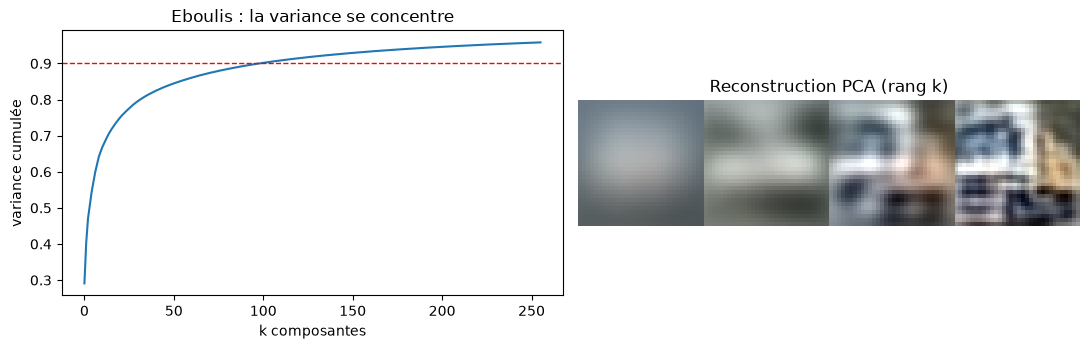

variance expliquée : k=64 -> 0.86 | k=256 -> 0.96


In [9]:
from sklearn.decomposition import PCA
Xc_tr = X_train - X_train.mean(0)
Xc_te = X_test  - X_train.mean(0)

pca = PCA(n_components=256, svd_solver="randomized", random_state=0).fit(Xc_tr)
var = np.cumsum(pca.explained_variance_ratio_)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].plot(var); ax[0].axhline(0.9, color="r", ls="--", lw=1)
ax[0].set_xlabel("k composantes"); ax[0].set_ylabel("variance cumulée")
ax[0].set_title("Eboulis : la variance se concentre")
# reconstruction d'une image pour quelques k
img0 = Xc_tr[1]
ax[1].axis("off"); ax[1].set_title("Reconstruction PCA (rang k)")
ks = [4, 16, 64, 256]
canvas = []
for k in ks:
    rec = (pca.transform(img0[None])[:, :k] @ pca.components_[:k]) + X_train.mean(0)
    canvas.append(to_img(np.clip(rec,0,255))[0].astype("uint8"))
ax[1].imshow(np.concatenate(canvas, 1))
ax[1].set_xticks([16+32*i for i in range(len(ks))]); ax[1].set_xticklabels([f"k={k}" for k in ks])
ax[1].set_yticks([])
plt.tight_layout(); plt.show()
print("variance expliquée : k=64 ->", f"{var[63]:.2f}", "| k=256 ->", f"{var[255]:.2f}")


In [10]:
# Sonde linéaire : on entraîne le classifieur sur un sous-échantillon de 10 000
# images (même taille pour toutes les représentations → comparaison équitable et
# rapide) et on évalue sur les 10 000 images de test.
print(f"{'représentation':<28}{'dim':>6}{'acc test':>10}")
print("-" * 44)
res7 = {}
nP = 10000
# référence : pixels bruts
ref = make_pipeline(StandardScaler(), LinearSVC(C=0.01, dual="auto", max_iter=3000)).fit(X_train[:nP], y_train[:nP])
res7["pixels bruts (3072)"] = accuracy_score(y_test, ref.predict(X_test))
print(f"{'pixels bruts':<28}{3072:>6}{res7['pixels bruts (3072)']:>10.3f}")
PtrA, PteA = pca.transform(Xc_tr), pca.transform(Xc_te)   # projeté une seule fois
for k in [32, 64, 128, 256]:
    clf = make_pipeline(StandardScaler(),
                        LinearSVC(C=0.05, dual="auto", max_iter=3000)).fit(PtrA[:nP, :k], y_train[:nP])
    a = accuracy_score(y_test, clf.predict(PteA[:, :k]))
    print(f"{'PCA + sonde linéaire':<28}{k:>6}{a:>10.3f}")
res7["PCA-256 + sonde"] = a


représentation                 dim  acc test
--------------------------------------------


pixels bruts                  3072     0.323
PCA + sonde linéaire            32     0.360


PCA + sonde linéaire            64     0.376


PCA + sonde linéaire           128     0.382


PCA + sonde linéaire           256     0.380


## 7.2 Dictionnaire appris par K-means

Idée (inspirée de Coates & Ng) : un dictionnaire appris par K-means sur des
patches, suivi d'un classifieur linéaire, fait nettement mieux que les pixels
bruts, et sans étiquettes.

**K-means.** Apprend $K$ centroïdes $c_1,\dots,c_K$ qui minimisent
$\sum_i \min_k \lVert p_i-c_k\rVert^2$ (algorithme de Lloyd : on alterne
assignation et moyenne, l'objectif décroît à chaque étape et converge vers un
minimum local). Les centroïdes servent de dictionnaire adapté aux données.

**Pipeline.**
1. **Patches** $6\times6\times3$ tirés au hasard, normalisés (centrage + variance
   unité par patch).
2. **Blanchiment ZCA** : $p\mapsto W p$ avec $W=U(\Lambda+\varepsilon I)^{-1/2}U^\top$
   ($U,\Lambda$ : covariance des patches), pour décorréler les pixels.
3. **Dictionnaire** : K-means sur les patches blanchis.
4. **Encodage** d'une image : sur chaque patch $p$, activation *triangle*
   $f_k(p)=\max\!\big(0,\ \bar d(p)-\lVert p-c_k\rVert\big)$, où $\bar d$ est la
   distance moyenne aux centroïdes.
5. **Pooling** par quadrants ($2\times2$) → $4K$ features, passées à un SVM
   linéaire.

En pratique, blanchiment + K-means donnent des détecteurs de bords et de
couleurs, et le pooling apporte un peu d'invariance.

Dictionnaire appris : 256 centroïdes en 0.5s


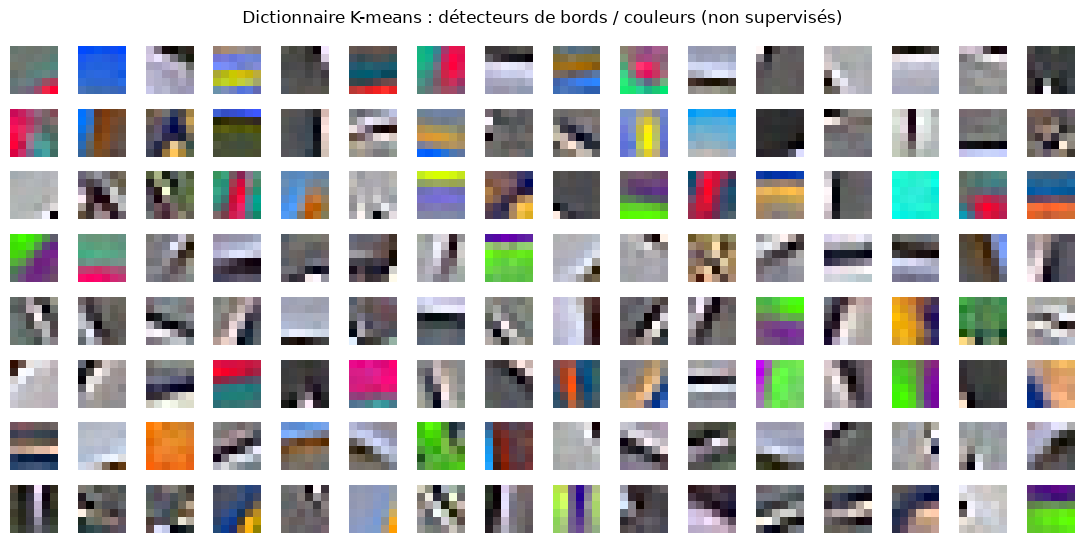

In [11]:
from sklearn.cluster import MiniBatchKMeans

P = 6                       # taille de patch
Kdict = 256                 # taille du dictionnaire
EPS_C, EPS_Z = 10.0, 0.1    # régul. contraste / blanchiment

def random_patches(I, n):
    i = rng.integers(0, len(I), n); a = rng.integers(0, 32-P+1, n); b = rng.integers(0, 32-P+1, n)
    return np.stack([I[k, x:x+P, z:z+P, :].ravel() for k, x, z in zip(i, a, b)]).astype("float32")

t = time.time()
patches = random_patches(I_train, 100000)
patches = (patches - patches.mean(1, keepdims=True)) / np.sqrt(patches.var(1, keepdims=True) + EPS_C)
pmean = patches.mean(0); Pc = patches - pmean
U, S, _ = np.linalg.svd(Pc.T @ Pc / len(Pc))         # covariance des patches
Wzca = U @ np.diag(1/np.sqrt(S + EPS_Z)) @ U.T        # blanchiment ZCA
km = MiniBatchKMeans(Kdict, batch_size=1000, n_init=3, max_iter=100, random_state=0).fit(Pc @ Wzca)
C = km.cluster_centers_
print(f"Dictionnaire appris : {Kdict} centroïdes en {time.time()-t:.1f}s")

# visualisation du dictionnaire (centroïdes ramenés en patches)
fig, ax = plt.subplots(8, 16, figsize=(11, 5.5))
for k, a in enumerate(ax.ravel()):
    patch = C[k].reshape(P, P, 3); patch = (patch - patch.min()) / (np.ptp(patch) + 1e-9)
    a.imshow(patch); a.axis("off")
plt.suptitle("Dictionnaire K-means : détecteurs de bords / couleurs (non supervisés)")
plt.tight_layout(); plt.show()


In [12]:
def encode(I, nimg, batch=500):
    I = I[:nimg]; n = len(I); pos = list(range(0, 32-P+1)); npos = len(pos)
    F = np.zeros((n, 4*Kdict), dtype="float32")
    Cn = (C**2).sum(1)
    for bi in range(0, n, batch):
        B = I[bi:bi+batch]; nb = len(B)
        cols = [B[:, a:a+P, b:b+P, :].reshape(nb, -1) for a in pos for b in pos]
        Pt = np.stack(cols, 1)                                            # (nb, npos², dim)
        Pt = (Pt - Pt.mean(2, keepdims=True)) / np.sqrt(Pt.var(2, keepdims=True) + EPS_C)
        Pt = (Pt.reshape(-1, P*P*3) - pmean) @ Wzca                       # blanchiment
        d = np.sqrt(np.maximum(-2*Pt@C.T + (Pt**2).sum(1, keepdims=True) + Cn, 0))
        act = np.maximum(0, d.mean(1, keepdims=True) - d).reshape(nb, npos, npos, Kdict)
        h = npos // 2
        F[bi:bi+nb, 0*Kdict:1*Kdict] = act[:, :h, :h].sum((1, 2))
        F[bi:bi+nb, 1*Kdict:2*Kdict] = act[:, :h, h:].sum((1, 2))
        F[bi:bi+nb, 2*Kdict:3*Kdict] = act[:, h:, :h].sum((1, 2))
        F[bi:bi+nb, 3*Kdict:4*Kdict] = act[:, h:, h:].sum((1, 2))
    return F

t = time.time()
n_tr, n_te = 10000, 10000
Ftr = encode(I_train, n_tr); Fte = encode(I_test, n_te)
print(f"Encodage {n_tr}+{n_te} images en {time.time()-t:.1f}s  (dim = {Ftr.shape[1]} = 4·K)")
clf = make_pipeline(StandardScaler(), LinearSVC(C=0.01, dual="auto", max_iter=3000)).fit(Ftr, y_train[:n_tr])
acc_dict = accuracy_score(y_test[:n_te], clf.predict(Fte))
res7["Dict. K-means + SVM lin."] = acc_dict
print(f"Dictionnaire K-means + SVM linéaire : acc test = {acc_dict:.3f}")


Encodage 10000+10000 images en 9.5s  (dim = 1024 = 4·K)


Dictionnaire K-means + SVM linéaire : acc test = 0.659


## 7.3 Bilan — Exercice 7

| Représentation | dim | acc (sonde lin.) |
|---|---|---|
| Pixels bruts | 3072 | ~0.32 |
| PCA | 256 | ~0.38 |
| Dictionnaire K-means | 1024 | ~0.66 |

Une représentation apprise sans étiquettes (dictionnaire K-means) rend la tâche
beaucoup plus séparable linéairement : un simple SVM linéaire passe de ~32 % à
~66 %. Sur CIFAR, la difficulté est donc surtout dans la représentation, pas dans
le classifieur. En augmentant la taille du dictionnaire on peut gagner encore un
peu (Coates & Ng montent jusqu'à ~77 %).

In [13]:
print(f"{'représentation':<28}{'dim':>6}{'acc test':>10}")
print("-" * 44)
for k in ["pixels bruts (3072)", "PCA-256 + sonde", "Dict. K-means + SVM lin."]:
    print(f"{k:<28}{'-':>6}{res7[k]:>10.3f}")


représentation                 dim  acc test
--------------------------------------------
pixels bruts (3072)              -     0.323
PCA-256 + sonde                  -     0.380
Dict. K-means + SVM lin.         -     0.659


# Conclusion

- **Ex 6** : le SVM est un problème d'optimisation convexe que l'on résout via son
  dual (Lagrangien, KKT, vecteurs supports) ; le kernel trick fait passer la
  non-linéarité dans un espace de features, et Nyström rend ce noyau explicite par
  une diagonalisation $W=U\Lambda U^\top$ pour passer à l'échelle.
- **Ex 7** : la PCA et le dictionnaire K-means apprennent des représentations sans
  étiquettes, évaluées par une sonde linéaire ; le blanchiment ZCA repose lui aussi
  sur une diagonalisation.

On retrouve donc deux outils principaux : l'optimisation convexe (SVM) et la
diagonalisation des matrices symétriques (PCA, blanchiment, Nyström).